# Plot2Code Dataset Generation

This notebook generates a dataset of matplotlib plots and their corresponding code for training a vision-language model to generate plotting code from images.

## Setup and Configuration

In [1]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

from pathlib import Path
import shutil
import os

import subprocess

from tqdm import tqdm
import json

import io
import re
import json
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from IPython.display import display, Markdown

## Step 1: Download Matplotlib Examples

Download matplotlib examples repository using sparse checkout to get only the galleries/examples directory.

## Step 2: Filter Example Categories

Keep only specific plot categories and remove others to focus on relevant plot types.

In [2]:
import os, json, subprocess
from pathlib import Path
from tqdm import tqdm

# --- Define paths ---
root_dir = Path().resolve()                         # current working directory
mpl_root = root_dir / "mpl_examples"                # local copy of Matplotlib examples
gallery_dir = root_dir / "plot_gallery_exec"
dataset_file = root_dir / "plot2code_exec.jsonl"

keep = [
    "lines_bars_and_markers",
    "statistics",
    "pie_and_polar_charts",
    "mplot3d",
]

gallery_dir.mkdir(exist_ok=True, parents=True)

print(f"📂 Searching for examples under: {mpl_root}")
print(f"💾 Output dataset: {dataset_file}")

# --- Skip if already exists ---
if dataset_file.exists() and dataset_file.stat().st_size > 1000:
    print(f"✅ Dataset file '{dataset_file.name}' already exists ({dataset_file.stat().st_size/1e6:.1f} MB). Skipping generation.")
    print("🗑️  Delete it if you want to regenerate.")
else:
    dataset = []
    examples = [
        f for f in mpl_root.rglob("*.py")
        if any(k in str(f) for k in keep)
    ]
    print(f"🧮 Found {len(examples)} example scripts to process")

    for f in tqdm(examples, desc="⏳ Generating plots"):
        out_png = gallery_dir / (f.stem + ".png")
        try:
            code = f.read_text()
            # Run each example in an isolated subprocess with Agg backend
            cmd = f"""
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt, numpy as np
exec(open(r'{f}').read(), {{'plt': plt, 'np': np}})
plt.savefig(r'{out_png}', bbox_inches='tight', dpi=150)
"""
            subprocess.run(
                ["python", "-c", cmd],
                check=True,
                timeout=20,
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL,
            )
            if out_png.exists():
                dataset.append({"image": str(out_png), "code": code})
        except Exception as e:
            print(f"⚠️ {f.name}: {e}")

    # --- Save JSONL ---
    with open(dataset_file, "w") as f:
        for d in dataset:
            f.write(json.dumps(d) + "\n")

    print(f"✅ Generated {len(dataset)} valid (image, code) pairs")
    print(f"📁 Saved to {dataset_file.resolve()}")


📂 Searching for examples under: /home/nipun.batra/git/plot2code/mpl_examples
💾 Output dataset: /home/nipun.batra/git/plot2code/plot2code_exec.jsonl
✅ Dataset file 'plot2code_exec.jsonl' already exists (0.3 MB). Skipping generation.
🗑️  Delete it if you want to regenerate.


## Step 3: Generate Dataset

Execute matplotlib example scripts and save the resulting plots with their source code.

## Step 4: Preview Dataset

Load and display random samples from the generated dataset.

Loaded 119 samples


### `voxels_torus.png`

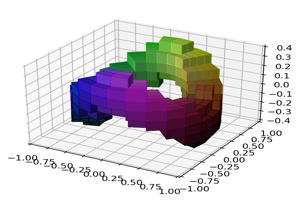

```python
"""
=======================================================
3D voxel / volumetric plot with cylindrical coordinates
=======================================================

Demonstrates using the *x*, *y*, *z* parameters of `.Axes3D.voxels`.
"""

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.colors


def midpoints(x):
    sl = ()
    for i in range(x.ndim):
        x = (x[s...
```

### `custom_shaded_3d_surface.png`

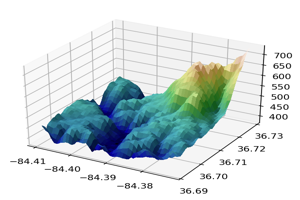

```python
"""
=======================================
Custom hillshading in a 3D surface plot
=======================================

Demonstrates using custom hillshading in a 3D surface plot.
"""

import matplotlib.pyplot as plt
import numpy as np

from matplotlib import cbook
from matplotlib.colors import LightSource

# Load and format data
dem = cbook.get_sample_data('jacksboro_fault_dem.npz')
z = dem[...
```

### `polar_legend.png`

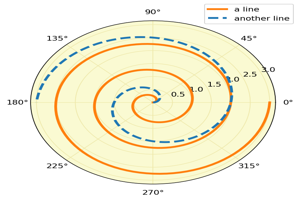

```python
"""
============
Polar legend
============

Using a legend on a polar-axis plot.
"""

import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()
ax = fig.add_subplot(projection="polar", facecolor="lightgoldenrodyellow")

r = np.linspace(0, 3, 301)
theta = 2 * np.pi * r
ax.plot(theta, r, color="tab:orange", lw=3, label="a line")
ax.plot(0.5 * theta, r, color="tab:blue", ls="--", lw=3, l...
```

### `lines_with_ticks_demo.png`

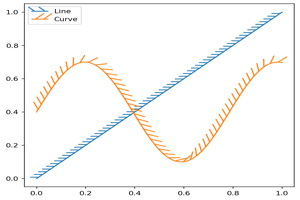

```python
"""
==============================
Lines with a ticked patheffect
==============================

Ticks can be added along a line to mark one side as a barrier using
`~matplotlib.patheffects.TickedStroke`.  You can control the angle,
spacing, and length of the ticks.

The ticks will also appear appropriately in the legend.

"""

import matplotlib.pyplot as plt
import numpy as np

from matplotlib i...
```

### `quiver3d.png`

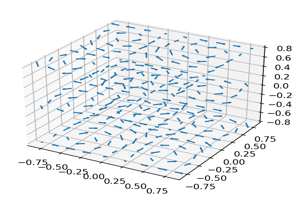

```python
"""
==============
3D quiver plot
==============

Demonstrates plotting directional arrows at points on a 3D meshgrid.
"""

import matplotlib.pyplot as plt
import numpy as np

ax = plt.figure().add_subplot(projection='3d')

# Make the grid
x, y, z = np.meshgrid(np.arange(-0.8, 1, 0.2),
                      np.arange(-0.8, 1, 0.2),
                      np.arange(-0.8, 1, 0.8))

# Make the directi...
```

In [3]:
import json
import random
from PIL import Image
from IPython.display import display, Markdown

# Load dataset
data = [json.loads(l) for l in open("plot2code_exec.jsonl")]

print(f"Loaded {len(data)} samples")

# Show 5 random examples
for sample in random.sample(data, min(5, len(data))):
    display(Markdown(f"### `{Path(sample['image']).name}`"))
    display(Image.open(sample["image"]).resize((300, 200)))
    display(Markdown(f"```python\n{sample['code'][:400]}...\n```"))

## Step 5: Load Vision-Language Model

Load the Qwen2.5-VL model for zero-shot plot code generation.

In [4]:
import torch
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

# Model configuration
model_id = "Qwen/Qwen2.5-VL-7B-Instruct"
dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

# Load processor and model
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=dtype,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="sdpa",  # Important on CUDA 12.4
)

# Set pad_token_id to eos to avoid device-side asserts
eos_id = processor.tokenizer.eos_token_id
model.generation_config.eos_token_id = eos_id
model.generation_config.pad_token_id = eos_id

/home/nipun.batra/.uv/nb-base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 5/5 [00:03<00:00,  1.38it/s]


## Step 6: Define Code Generation Function

Create a function to generate matplotlib code from plot images.

In [5]:
from PIL import Image

def gen_code_for_image(img_path, max_new_tokens=512, temperature=0.0):
    """
    Generate matplotlib code from a plot image using the VLM.
    
    Args:
        img_path: Path to the input image
        max_new_tokens: Maximum number of tokens to generate
        temperature: Sampling temperature (0.0 for deterministic)
    
    Returns:
        Generated code as a string
    """
    img = Image.open(img_path).convert("RGB")

    # Construct the prompt message
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text",
             "text": ("You are a Matplotlib expert. "
                      "Write minimal runnable Python code to recreate this plot. "
                      "Use only matplotlib.pyplot (and numpy if needed). "
                      "Return ONLY a fenced Python code block.")
            },
        ],
    }]

    # Apply chat template to create string with special vision tokens
    convo = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # Process text and image together
    inputs = processor(text=[convo], images=[img], return_tensors="pt").to(model.device, dtype)

    # Generate code
    with torch.inference_mode():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=False,
            use_cache=True,
        )
    return processor.batch_decode(out, skip_special_tokens=True)[0]

## Step 7: Test Code Generation

Test the code generation on a single example image.

In [6]:
# Demo on one image
print(gen_code_for_image("plot_gallery_exec/simple_plot.png"))

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


system
You are a helpful assistant.
user
You are a Matplotlib expert. Write minimal runnable Python code to recreate this plot. Use only matplotlib.pyplot (and numpy if needed). Return ONLY a fenced Python code block.
assistant
```python
import numpy as np
import matplotlib.pyplot as plt

# Generate data
t = np.linspace(0, 2, 400)
voltage = np.sin(2 * np.pi * t)

# Plot the data
plt.plot(t, voltage, label='Voltage (mV)')
plt.xlabel('time (s)')
plt.ylabel('voltage (mV)')
plt.title('About as simple as it gets, folks')
plt.legend()
plt.grid(True)
plt.show()
```


## Step 8: Define Evaluation Functions

Helper functions for extracting code, executing it, and computing similarity metrics.

In [7]:
import io, re, json, numpy as np, matplotlib, ast, textwrap
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from difflib import SequenceMatcher
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from IPython.display import display, Markdown

# ----------------------------------------
# Helper functions
# ----------------------------------------
def extract_code(text):
    """Extract fenced Python code from LLM output."""
    m = re.search(r"```(?:python)?\s*([\s\S]*?)```", text)
    return m.group(1).strip() if m else text.strip()

def render_code_to_png(py_code, out_path):
    """Safely execute Matplotlib code and save plot to PNG."""
    import builtins
    safe_builtins = {
        "range": range, "len": len, "print": print, "__import__": builtins.__import__,
    }
    safe_globals = {"__builtins__": safe_builtins, "np": __import__("numpy"), "plt": plt}
    plt.close("all")
    try:
        exec(py_code, safe_globals, None)
        if not plt.get_fignums():
            plt.figure()
        plt.savefig(out_path, bbox_inches="tight", dpi=150)
        plt.close("all")
        return True
    except Exception as e:
        print(f"⚠️ Execution failed: {e}")
        return False

def image_ssim(img_a, img_b):
    """Compute SSIM similarity between two images."""
    a = np.array(Image.open(img_a).convert("L"))
    b = np.array(Image.open(img_b).convert("L"))
    h, w = min(a.shape[0], b.shape[0]), min(a.shape[1], b.shape[1])
    a, b = a[:h, :w], b[:h, :w]
    return float(ssim(a, b))

def extract_calls(py_code):
    """Return list of Matplotlib function calls used in code."""
    try:
        tree = ast.parse(py_code)
    except Exception:
        return []
    calls = []
    for node in ast.walk(tree):
        if isinstance(node, ast.Call) and isinstance(node.func, ast.Attribute):
            calls.append(node.func.attr)
    return calls

def code_bleu(ref, gen):
    """Compute smoothed BLEU for short code snippets."""
    smoothie = SmoothingFunction().method1
    return sentence_bleu([ref.split()], gen.split(), smoothing_function=smoothie)

def code_edit_sim(ref, gen):
    """Edit-distance-based code similarity."""
    return SequenceMatcher(None, ref, gen).ratio()

def api_overlap_verbose(ref_code, gen_code):
    """Compute API overlap + show matched/missed calls."""
    ref_calls, gen_calls = set(extract_calls(ref_code)), set(extract_calls(gen_code))
    matched = ref_calls & gen_calls
    missed = ref_calls - gen_calls
    extras = gen_calls - ref_calls
    sim = len(matched) / len(ref_calls) if ref_calls else 0.0
    return sim, matched, missed, extras

# ----------------------------------------
# Unified verbose evaluator
# ----------------------------------------
def evaluate_plot2code_verbose(img_path, ref_code):
    print(f"\n🖼️ Evaluating: {img_path}")
    print("=" * 80)

    # --- Generate ---
    result_text = gen_code_for_image(img_path)
    code = extract_code(result_text)

    # --- Show generated code (truncated) ---
    print("\n🧠 Model Output (first 20 lines):")
    print("-" * 80)
    print("\n".join(code.splitlines()[:20]))
    print("-" * 80)

    # --- Execute and render ---
    gen_path = "recreated.png"
    ok = render_code_to_png(code, gen_path)
    if not ok:
        print("❌ Code execution failed.")
        return

    # --- Compute metrics ---
    ssim_score = image_ssim(img_path, gen_path)
    bleu = code_bleu(ref_code, code)
    edit_sim = code_edit_sim(ref_code, code)
    api_sim, matched, missed, extras = api_overlap_verbose(ref_code, code)

    # --- Log API details ---
    print("\n🔧 API Usage Analysis")
    print("-" * 80)
    print(f"Reference APIs ({len(matched)+len(missed)}): {sorted(extract_calls(ref_code))}")
    print(f"Generated APIs ({len(matched)+len(extras)}): {sorted(extract_calls(code))}")
    print(f"✅ Matched: {sorted(matched)}")
    print(f"❌ Missed (in ref but not gen): {sorted(missed)}")
    print(f"➕ Extra (in gen but not ref): {sorted(extras)}")

    # --- Combine metrics ---
    code_score = 0.4*bleu + 0.3*edit_sim + 0.3*api_sim
    overall = 0.5*ssim_score + 0.5*code_score

    print("\n📊 Quantitative Scores")
    print("-" * 80)
    print(f"SSIM (Visual):       {ssim_score:.3f}")
    print(f"BLEU (Text):         {bleu:.3f}")
    print(f"Edit Similarity:     {edit_sim:.3f}")
    print(f"API Overlap:         {api_sim:.3f}")
    print(f"Composite CodeScore: {code_score:.3f}")
    print(f"Overall Score:       {overall:.3f}")
    print("=" * 80)

    # --- Display visual comparison ---
    ref_img = Image.open(img_path).resize((400, 300))
    gen_img = Image.open(gen_path).resize((400, 300))
    side = Image.new("RGB", (800, 300))
    side.paste(ref_img, (0, 0))
    side.paste(gen_img, (400, 0))

    display(Markdown(f"### 🧩 Evaluation Summary: `{Path(img_path).name}`"))
    display(Markdown(f"""
**Visual:** SSIM `{ssim_score:.3f}`  
**Code:** BLEU `{bleu:.3f}` · Edit `{edit_sim:.3f}` · API `{api_sim:.3f}`  
**API Details:** ✅ `{matched}` · ❌ `{missed}` · ➕ `{extras}`  
**Aggregate:** CodeScore `{code_score:.3f}` · Overall `{overall:.3f}`
"""))
    display(side)


## Step 9: Run Evaluation

Evaluate the model on a sample plot.


🖼️ Evaluating: plot_gallery_exec/simple_plot.png

🧠 Model Output (first 20 lines):
--------------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# Generate data
t = np.linspace(0, 2, 400)
voltage = np.sin(2 * np.pi * t)

# Plot the data
plt.plot(t, voltage, label='Voltage (mV)')
plt.xlabel('time (s)')
plt.ylabel('voltage (mV)')
plt.title('About as simple as it gets, folks')
plt.legend()
plt.grid(True)
plt.show()
--------------------------------------------------------------------------------

🔧 API Usage Analysis
--------------------------------------------------------------------------------
Reference APIs (6): ['bar', 'linspace', 'rand', 'rand', 'seed', 'show', 'subplot']
Generated APIs (9): ['grid', 'legend', 'linspace', 'plot', 'show', 'sin', 'title', 'xlabel', 'ylabel']
✅ Matched: ['linspace', 'show']
❌ Missed (in ref but not gen): ['bar', 'rand', 'seed', 'subplot']
➕ Extra (in gen but not ref): ['grid', 'lege

### 🧩 Evaluation Summary: `simple_plot.png`


**Visual:** SSIM `0.732`  
**Code:** BLEU `0.021` · Edit `0.008` · API `0.333`  
**API Details:** ✅ `{'linspace', 'show'}` · ❌ `{'seed', 'rand', 'subplot', 'bar'}` · ➕ `{'ylabel', 'grid', 'plot', 'legend', 'sin', 'xlabel', 'title'}`  
**Aggregate:** CodeScore `0.111` · Overall `0.421`


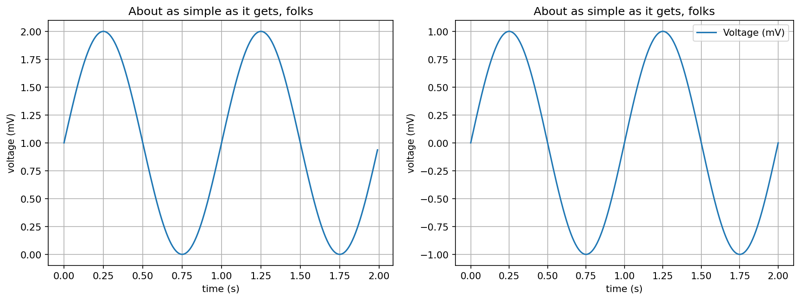

In [9]:
# load reference code from your dataset
with open("plot2code_exec.jsonl") as f:
    ref_data = json.loads(next(f))
ref_code = ref_data["code"]

evaluate_plot2code_verbose("plot_gallery_exec/simple_plot.png", ref_code)

### Finetuning 


In [12]:
import torch, os
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoProcessor,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------
dataset = load_dataset("json", data_files="plot2code_exec.jsonl")["train"]
dataset = dataset.train_test_split(test_size=0.1, seed=42)
train_ds, val_ds = dataset["train"], dataset["test"]

# ------------------------------------------------------------
# 2. Load model + processor
# ------------------------------------------------------------
model_id = "Qwen/Qwen2.5-VL-7B-Instruct"

dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=dtype,
    device_map="auto",
    attn_implementation="flash_attention_2",
    trust_remote_code=True,
)
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

# ------------------------------------------------------------
# 3. Prepare chat-style data
# ------------------------------------------------------------
from PIL import Image

def preprocess(example):
    message = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": Image.open(example["image"]).convert("RGB")},
                {"type": "text", "text": "You are a Matplotlib expert. Write minimal runnable Python code to recreate this plot."},
            ],
        },
        {"role": "assistant", "content": [{"type": "text", "text": example["code"]}]},
    ]
    example["messages"] = message
    return example

train_ds = train_ds.map(preprocess)
val_ds   = val_ds.map(preprocess)

# ------------------------------------------------------------
# 4. Collate function
# ------------------------------------------------------------
def collate_fn(examples):
    texts  = [processor.apply_chat_template(e["messages"], tokenize=False) for e in examples]
    images = [e["messages"][0]["content"][0]["image"] for e in examples]
    batch  = processor(text=texts, images=images, padding=True, return_tensors="pt")
    batch["labels"] = batch["input_ids"].clone()
    return batch

# ------------------------------------------------------------
# 5. Apply LoRA
# ------------------------------------------------------------
lora_cfg = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
)
model = get_peft_model(model, lora_cfg)

Generating train split: 119 examples [00:00, 19303.17 examples/s]
`torch_dtype` is deprecated! Use `dtype` instead!


ValueError: Unrecognized configuration class <class 'transformers.models.qwen2_5_vl.configuration_qwen2_5_vl.Qwen2_5_VLConfig'> for this kind of AutoModel: AutoModelForCausalLM.
Model type should be one of ApertusConfig, ArceeConfig, AriaTextConfig, BambaConfig, BartConfig, BertConfig, BertGenerationConfig, BigBirdConfig, BigBirdPegasusConfig, BioGptConfig, BitNetConfig, BlenderbotConfig, BlenderbotSmallConfig, BloomConfig, BltConfig, CamembertConfig, LlamaConfig, CodeGenConfig, CohereConfig, Cohere2Config, CpmAntConfig, CTRLConfig, Data2VecTextConfig, DbrxConfig, DeepseekV2Config, DeepseekV3Config, DiffLlamaConfig, DogeConfig, Dots1Config, ElectraConfig, Emu3Config, ErnieConfig, Ernie4_5Config, Ernie4_5_MoeConfig, Exaone4Config, FalconConfig, FalconH1Config, FalconMambaConfig, FlexOlmoConfig, FuyuConfig, GemmaConfig, Gemma2Config, Gemma3Config, Gemma3TextConfig, Gemma3nConfig, Gemma3nTextConfig, GitConfig, GlmConfig, Glm4Config, Glm4MoeConfig, GotOcr2Config, GPT2Config, GPT2Config, GP

## TODO List

Future improvements and tasks:

1. Clean up notebook - if dataset exists, skip generation steps
2. Remove Unicode characters
3. Run in batch mode over all images
4. Report SSIM scores
5. Decouple data generation and model training notebooks
6. Decouple evaluation and zero-shot code gen
7. Add additional metrics - exec@1
8. Fine-tune model on this data
9. Keep a clean test set separate from training data
10. On test set evaluate zero shot and fine-tuned model